In [1]:
from nrem_sc.constants import PROCESSED_DATA_PATH, INTERIM_DATA_PATH, RAW_DATA_PATH
from nrem_sc.utils import group_by_ids, hd_tuning

from pycircstat2.hypothesis import rayleigh_test
from pycircstat2 import Circular

import numpy as np
import pandas as pd
import pynapple as nap
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from cmap import Colormap
from scipy.ndimage import gaussian_filter1d

if "cmocean:phase" not in mpl.colormaps:
    mpl.colormaps.register(Colormap("cmocean:phase").to_mpl())

In [2]:
SAMPLING_RATE = 20000.0
unit_id = "107b"
spikes = {}
offset = 0

for i in range(1, 3, 1):
    # Load spike times and cluster IDs
    clu = np.load(RAW_DATA_PATH / unit_id / f"YutaTest107b.clu.{i}.npy", mmap_mode="r").squeeze()
    res = np.load(RAW_DATA_PATH / unit_id / f"YutaTest107b.res.{i}.npy", mmap_mode="r").squeeze()
    
    clu = clu[1:]  # remove number of clusters at the beginning
    units = np.unique(clu).astype(int)
    units = units[(units != 0) & (units != 1)] # exclude noise and multiunit clusters
        
    results = group_by_ids(values=res/SAMPLING_RATE, ids=clu, select_ids=units)

    for i, (key, value) in enumerate(results.items()):
        # spikes[offset+i] = {'data': nap.Ts(value), 'original_id': int(key.item())}
        spikes[offset+i] = nap.Ts(value)
    offset += len(results)

spikes = nap.TsGroup(spikes)
print(f"Total units: {len(spikes)}")

Total units: 130


In [3]:
angle = nap.load_file(PROCESSED_DATA_PATH / unit_id / "angle_openfield.npz")
angle.shape

(6711591,)

In [4]:
angles_rad = np.deg2rad(angle) if angle.max() > 2 * np.pi else angle
n_bins = 60

tcs = nap.compute_tuning_curves(
    data=spikes, features=angles_rad,
    bins=n_bins,
    epochs=angles_rad.time_support,
    range=(0.0, 2*np.pi),
    feature_names=['head_direction']
)

tcs.values = gaussian_filter1d(tcs.values, sigma=1, axis=1, mode='wrap')

Text(0, 0.5, 'Firing Rate')

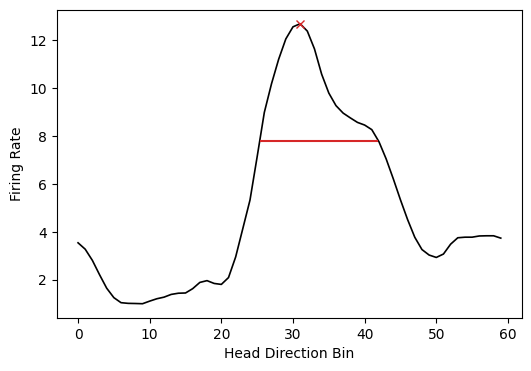

In [121]:
from scipy.signal import find_peaks, peak_widths

idx = 0
# data = np.hstack([tcs[idx].values, tcs[idx].values])
data = tcs[idx].values
peaks, _ = find_peaks(data, height=0.5*np.max(data), distance=n_bins)
widths = peak_widths(data, peaks, rel_height=0.5)

plt.figure(figsize=(6, 4))
plt.plot(data, color='k', linewidth=1.2)
plt.plot(peaks, data[peaks], "x", color='C3')
plt.hlines(*widths[1:], color="C3")
plt.xlabel("Head Direction Bin")
plt.ylabel("Firing Rate")
# plt.axvline(n_bins, color='r', linestyle='--', linewidth=0.7)

Text(0, 0.5, 'Firing Rate')

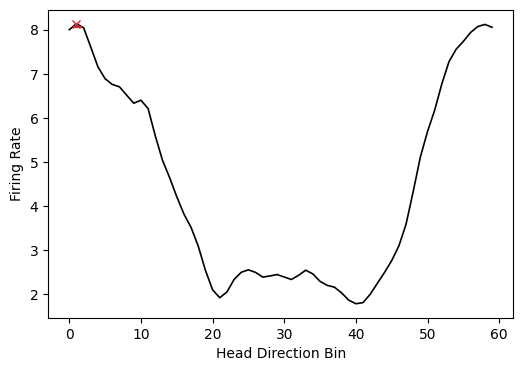

In [ ]:
from scipy.signal import find_peaks, peak_widths

idx = 39
# data = np.hstack([tcs[idx].values, tcs[idx].values])
data = tcs[idx].values
peaks, _ = find_peaks(data, height=0.5*np.max(data), distance=n_bins)
widths = peak_widths(data, peaks, rel_height=0.5)

plt.figure(figsize=(6, 4))
plt.plot(data, color='k', linewidth=1.2)
plt.plot(peaks, data[peaks], "x", color='C3')
plt.hlines(*widths[1:], color="C3")
plt.xlabel("Head Direction Bin")
plt.ylabel("Firing Rate")
# plt.axvline(n_bins, color='r', linestyle='--', linewidth=0.7)

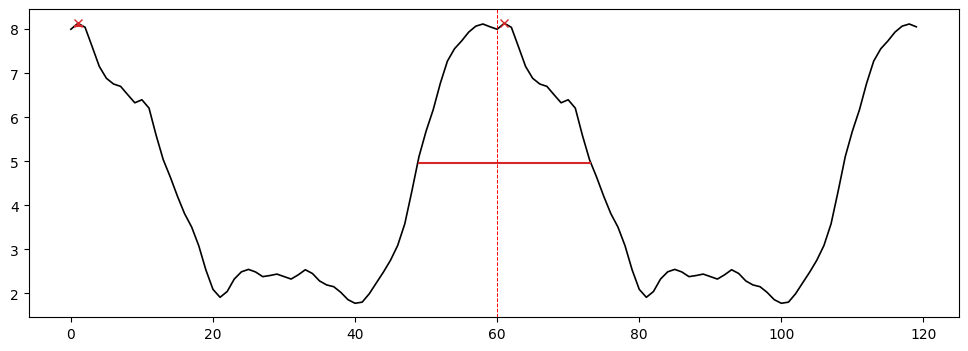

In [123]:
from scipy.signal import find_peaks, peak_widths

idx = 39
data = np.hstack([tcs[idx].values, tcs[idx].values])
peaks, _ = find_peaks(data, height=0.5*np.max(data), distance=n_bins)
widths = peak_widths(data, peaks, rel_height=0.5)


plt.figure(figsize=(12, 4))
plt.plot(data, color='k', linewidth=1.2)
plt.plot(peaks, data[peaks], "x", color='C3')
plt.hlines(*widths[1:], color="C3")
plt.axvline(n_bins, color='r', linestyle='--', linewidth=0.7)

In [124]:
def fwhm(tuning_curve: np.ndarray, bin_size: float) -> float:
    '''Compute largest full width at half maximum (FWHM) of a tuning curve.'''
    data = np.hstack([tuning_curve, tuning_curve]) # wrap to handle circular data
    peaks, _ = find_peaks(data, height=0.5*np.max(data), distance=len(tuning_curve))
    widths = peak_widths(data, peaks, rel_height=0.5)
    return np.max(widths[0]) * bin_size

fwhm(tcs[idx].values, 360 / n_bins)

np.float64(146.41751863989964)

In [8]:
circ_metadata = {'kappa': [], 'skewness': [], 'kurtosis': [], 'p_value': [], 'fwhm': []}
for unit_idx in range(len(tcs.unit)):
    if np.all(tcs[unit_idx].values == 0):
        circ_metadata['kappa'].append(0)
        circ_metadata['skewness'].append(0)
        circ_metadata['kurtosis'].append(0)
        circ_metadata['p_value'].append(1)
        circ_metadata['fwhm'].append(360)
        continue
    circ = Circular(tcs[unit_idx])
    circ_metadata['kappa'].append(circ.kappa)
    circ_metadata['skewness'].append(circ.skewness)
    circ_metadata['kurtosis'].append(circ.kurtosis)
    circ_metadata['p_value'].append(rayleigh_test(alpha=tcs[unit_idx]).pval)
    circ_metadata['fwhm'].append(fwhm(tcs[unit_idx].values, 360 / n_bins))

circ_metadata = pd.DataFrame(circ_metadata)
spikes.set_info(circ_metadata)
spikes.set_info({'pref_ang': tcs.idxmax('head_direction').values})
spikes

Index    rate     kappa          skewness    kurtosis    p_value    fwhm    pref_ang    ...
-------  -------  -------------  ----------  ----------  ---------  ------  ----------  -----
0        1.6999   252.4          -2.13       -1.53       0.01       110.44  3.3         ...
1        4.90334  9.33           -4.91       4.57        0.0        51.7    3.51        ...
2        3.9164   1712.28        -1.45       -0.34       0.0        118.25  3.93        ...
3        3.81898  1835.05        -1.56       -1.46       0.0        105.7   0.16        ...
4        6.08827  1630.77        -1.52       1.23        0.0        45.7    1.83        ...
5        2.22075  4977387155.97  -6.18       22003.97    0.0        15.33   0.37        ...
6        3.54915  1226.41        0.26        -1.84       0.22       204.89  3.93        ...
...      ...      ...            ...         ...         ...        ...     ...         ...
123      1.33592  74943.54       4.7         7.16        0.0        330.56  0.

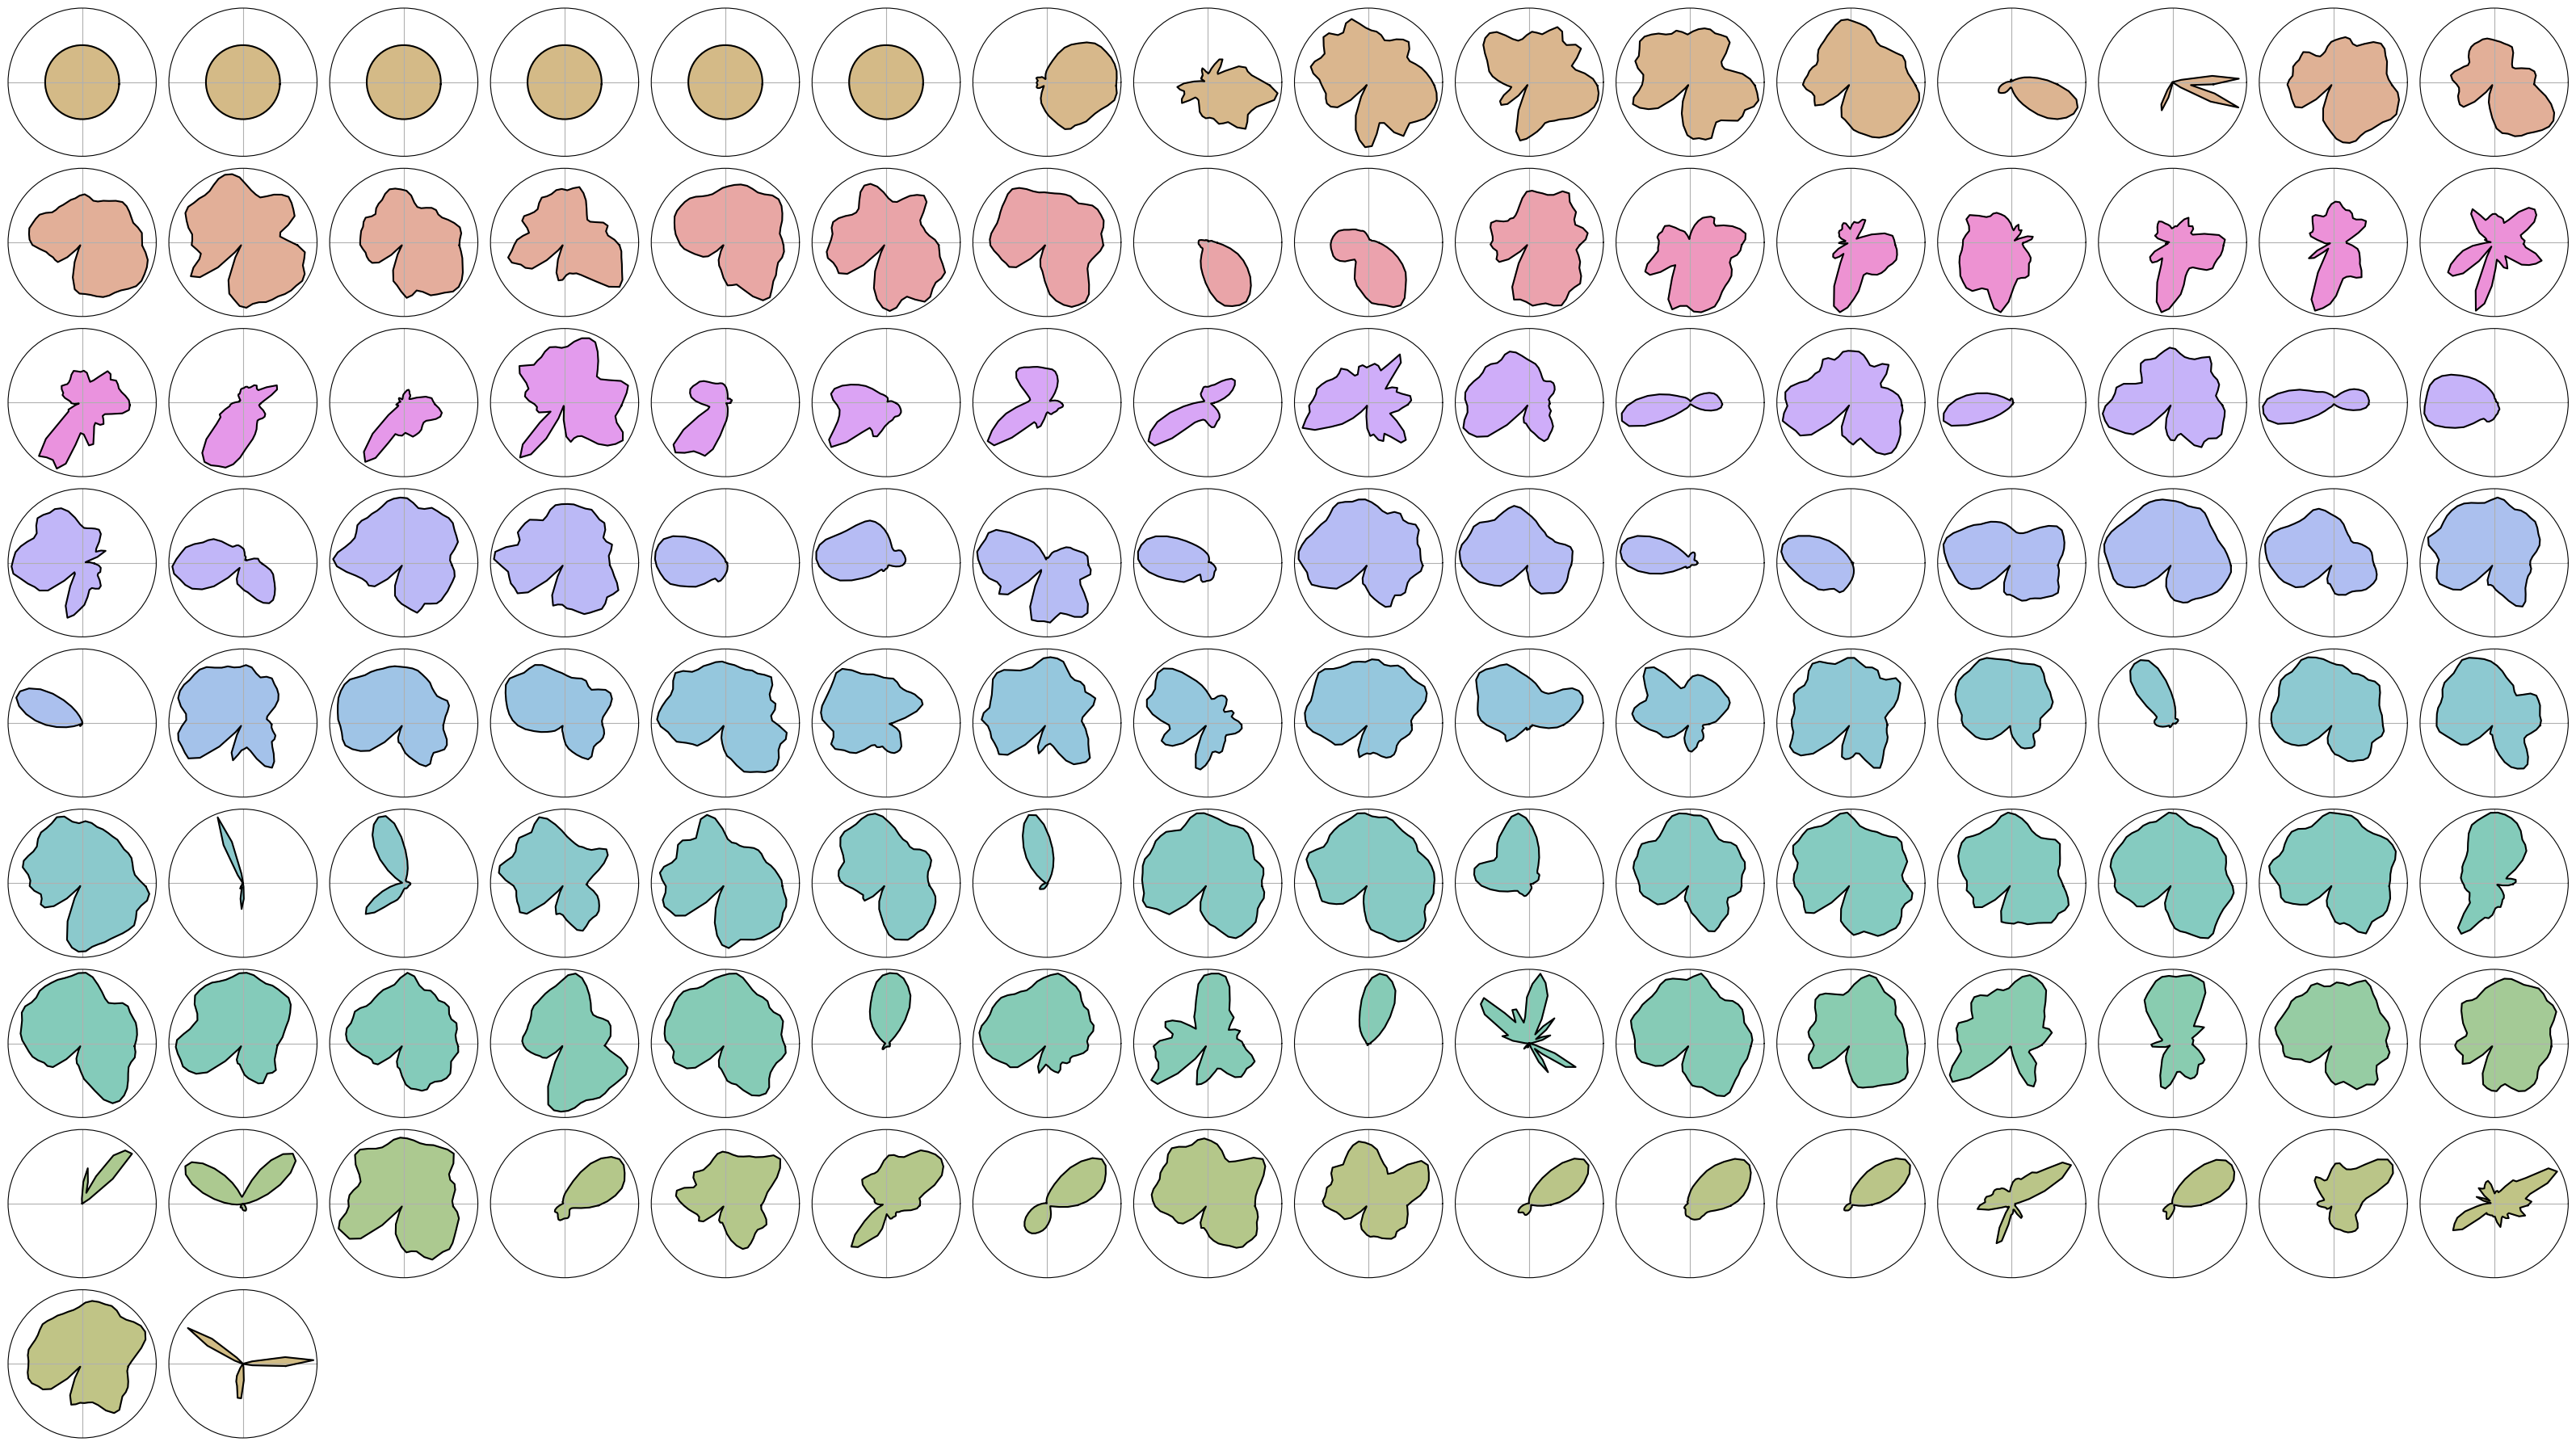

In [ ]:
norm = plt.Normalize(0, 2*np.pi)
cmap = plt.get_cmap("cmocean:phase")
colors = cmap(norm(spikes['pref_ang'].values))

sorted_idx = np.argsort(tcs.idxmax('head_direction').values)
n_units = len(spikes)

angles = np.hstack([tcs.coords["head_direction"], tcs.coords["head_direction"][0]])
ncols = 16
nrows = n_units // ncols + 1
figsize = (ncols*2, nrows*2)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize,
                         subplot_kw={'projection': 'polar', 'theta_direction': -1},
                        #  gridspec_kw={'wspace': 0.05, 'hspace': 0.3}
                         )
axes = axes.flatten()

for ax in axes:
    ax.set_visible(False)

for i, n in enumerate(sorted_idx):
    tuning_curve = np.hstack([tcs.values[n], tcs.values[n][0]])
    axes[i].plot(angles, tuning_curve, linewidth=1.5, color='k')
    axes[i].fill(angles, tuning_curve, color=colors[n], alpha=0.5)

    axes[i].set_visible(True)
    axes[i].set_yticks([])
    axes[i].set_xticks([0, np.pi/2, np.pi, 3*np.pi/2])
    axes[i].set_xticklabels([])
    # axes[i].set_title(f"{n}\n{circ_metadata.loc[n]['kappa']:.1f}\n{circ_metadata.loc[n]['p_value']:.2f}\n{circ_metadata.loc[n]['fwhm']:.1f}", fontsize=12)

# plt.tight_layout()

23


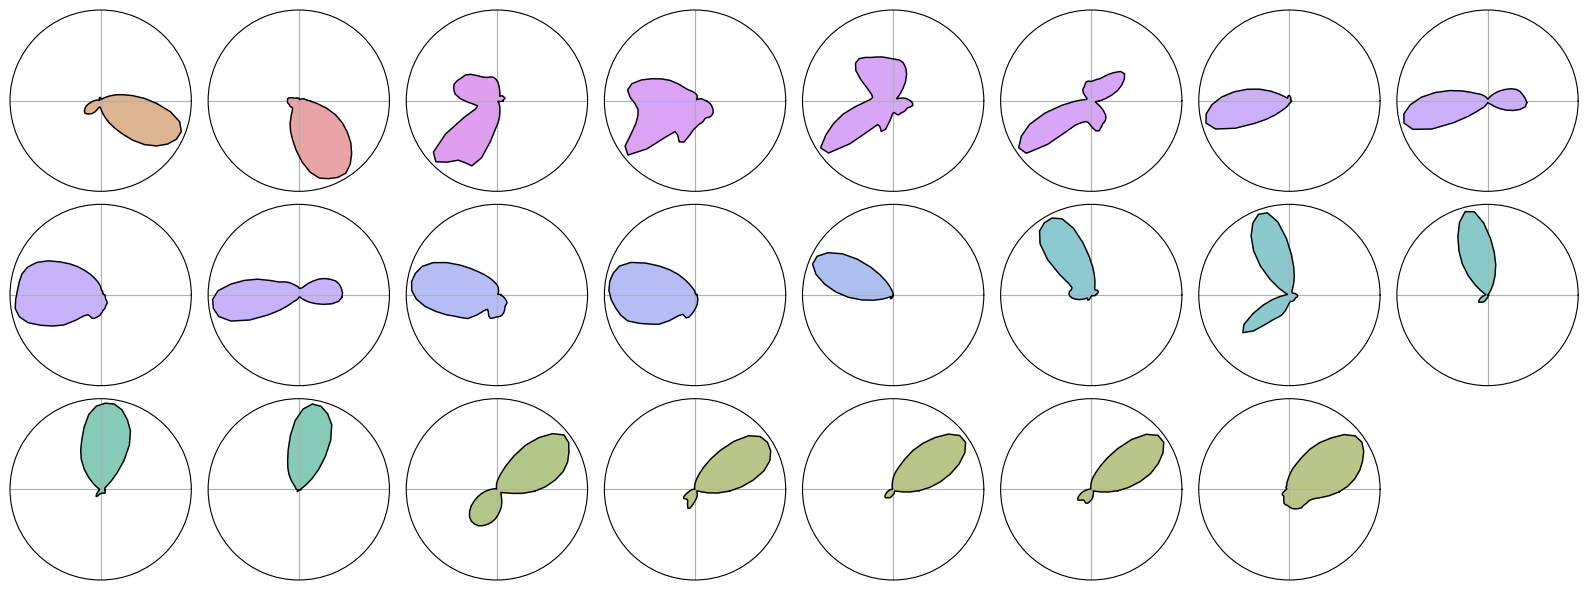

In [94]:
hd_spikes = spikes[(spikes['fwhm'] < 90) & (spikes['kappa'] < 1000) & (spikes['p_value'] < 0.05)]
print(len(hd_spikes))

angles = np.hstack([tcs.coords["head_direction"], tcs.coords["head_direction"][0]])

sorted_idx = hd_spikes.index[np.argsort(hd_spikes['pref_ang'].values)]
n_units = len(hd_spikes)

ncols = 8
nrows = n_units // ncols + 1
figsize = (ncols*2, nrows*2)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, subplot_kw={'projection': 'polar', 'theta_direction': -1})
axes = axes.flatten()

for ax in axes:
    ax.set_visible(False)

for i, n in enumerate(sorted_idx):
    tuning_curve = np.hstack([tcs.values[n], tcs.values[n][0]])
    axes[i].plot(angles, tuning_curve, linewidth=1, color='k')
    axes[i].fill(angles, tuning_curve, color=colors[n], alpha=0.5)

    axes[i].set_visible(True)
    axes[i].set_yticks([])
    axes[i].set_xticks([0, np.pi/2, np.pi, 3*np.pi/2])
    axes[i].set_xticklabels([])
    # axes[i].set_title(f"{n}\n{circ_metadata.loc[n]['kappa']:.1f}\n{circ_metadata.loc[n]['p_value']:.2f}\n{circ_metadata.loc[n]['fwhm']:.1f}", fontsize=8)

plt.tight_layout()

107


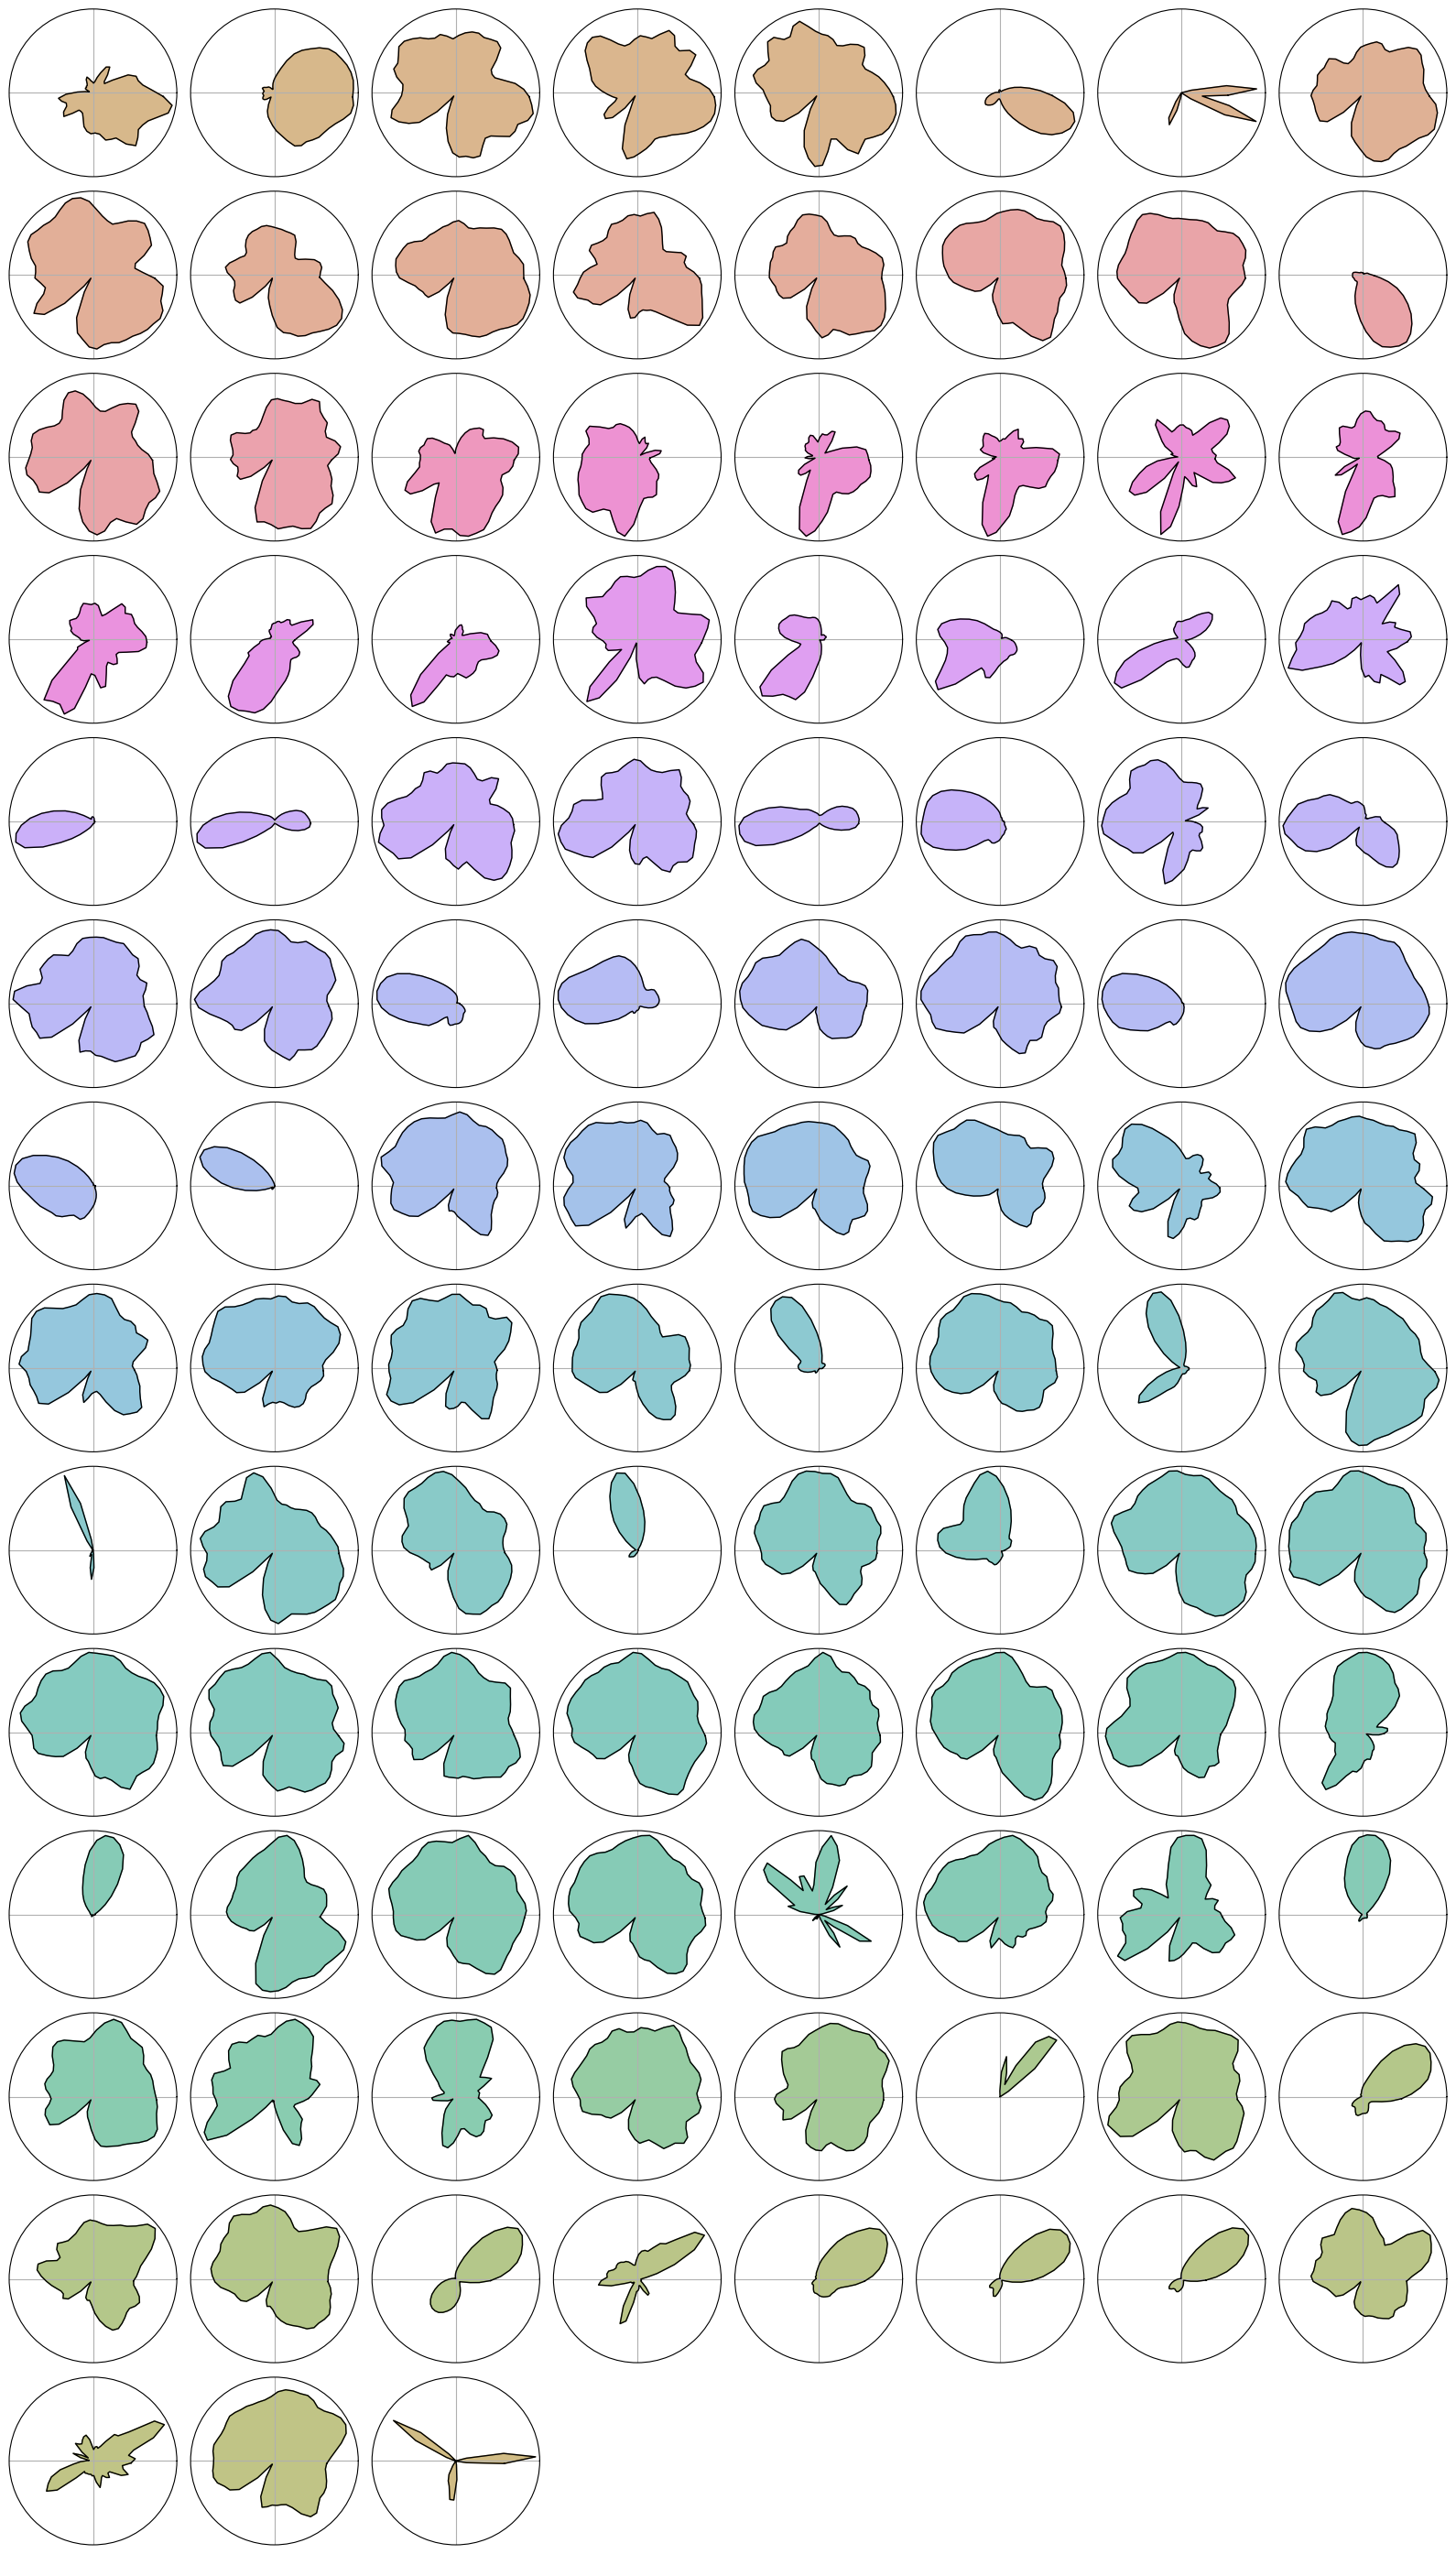

In [97]:
hd_spikes = spikes[(spikes['p_value'] < 0.01)]
print(len(hd_spikes))

angles = np.hstack([tcs.coords["head_direction"], tcs.coords["head_direction"][0]])

sorted_idx = hd_spikes.index[np.argsort(hd_spikes['pref_ang'].values)]
n_units = len(hd_spikes)

ncols = 8
nrows = n_units // ncols + 1
figsize = (ncols*2, nrows*2)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, subplot_kw={'projection': 'polar', 'theta_direction': -1})
axes = axes.flatten()

for ax in axes:
    ax.set_visible(False)

for i, n in enumerate(sorted_idx):
    tuning_curve = np.hstack([tcs.values[n], tcs.values[n][0]])
    axes[i].plot(angles, tuning_curve, linewidth=1, color='k')
    axes[i].fill(angles, tuning_curve, color=colors[n], alpha=0.5)

    axes[i].set_visible(True)
    axes[i].set_yticks([])
    axes[i].set_xticks([0, np.pi/2, np.pi, 3*np.pi/2])
    axes[i].set_xticklabels([])
    # axes[i].set_title(f"{n}\n{circ_metadata.loc[n]['kappa']:.1f}\n{circ_metadata.loc[n]['p_value']:.2f}\n{circ_metadata.loc[n]['fwhm']:.1f}", fontsize=8)

plt.tight_layout()

In [40]:
peak_fr = tcs.max('head_direction').values
norm_fr = peak_fr / np.max(peak_fr)

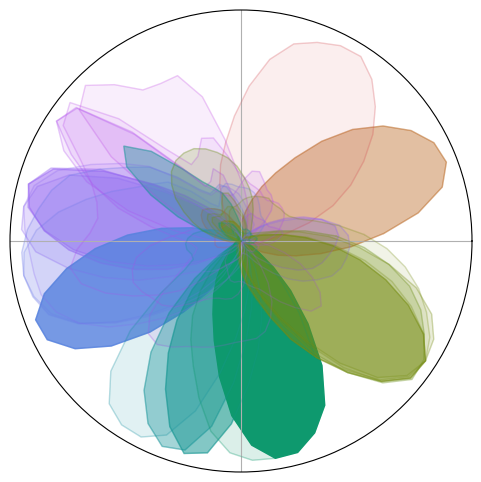

In [89]:
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': 'polar'})

for n in sorted_idx:
    norm = plt.Normalize()
    tuning_curve = np.hstack([tcs.values[n], tcs.values[n][0]])
    ax.plot(angles, norm(tuning_curve), linewidth=1, color=colors[n], alpha=0.2)
    ax.fill(angles, norm(tuning_curve), color=colors[n], alpha=norm_fr[n])
    # ax.fill(angles, norm(tcs[n]), color=fr_colors[n], alpha=0.8)
    
    ax.set_yticks([])
    ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2])
    ax.set_xticklabels([])

In [230]:
hd_spikes.drop_info(['kappa', 'skewness', 'kurtosis', 'p_value'])
hd_spikes.set_info({'order': np.argsort(hd_spikes['pref_ang']).values})
hd_spikes

Index    rate     fwhm    pref_ang    order
-------  -------  ------  ----------  -------
1        4.90334  51.7    3.51        3
12       2.0094   51.37   2.36        17
14       1.08584  50.01   4.24        1
15       2.46556  57.83   0.37        13
16       1.79704  51.44   2.98        10
17       1.88426  44.82   2.88        6
18       1.87837  35.34   2.57        7
...      ...      ...     ...         ...
53       1.06507  85.42   2.98        18
54       1.23341  72.7    0.99        12
60       1.51315  63.59   4.87        19
62       3.15509  60.52   5.6         11
64       3.02712  56.21   5.71        20
65       1.59498  53.4    5.71        21
67       1.55103  69.57   5.71        22

(-200.0, 560.0)

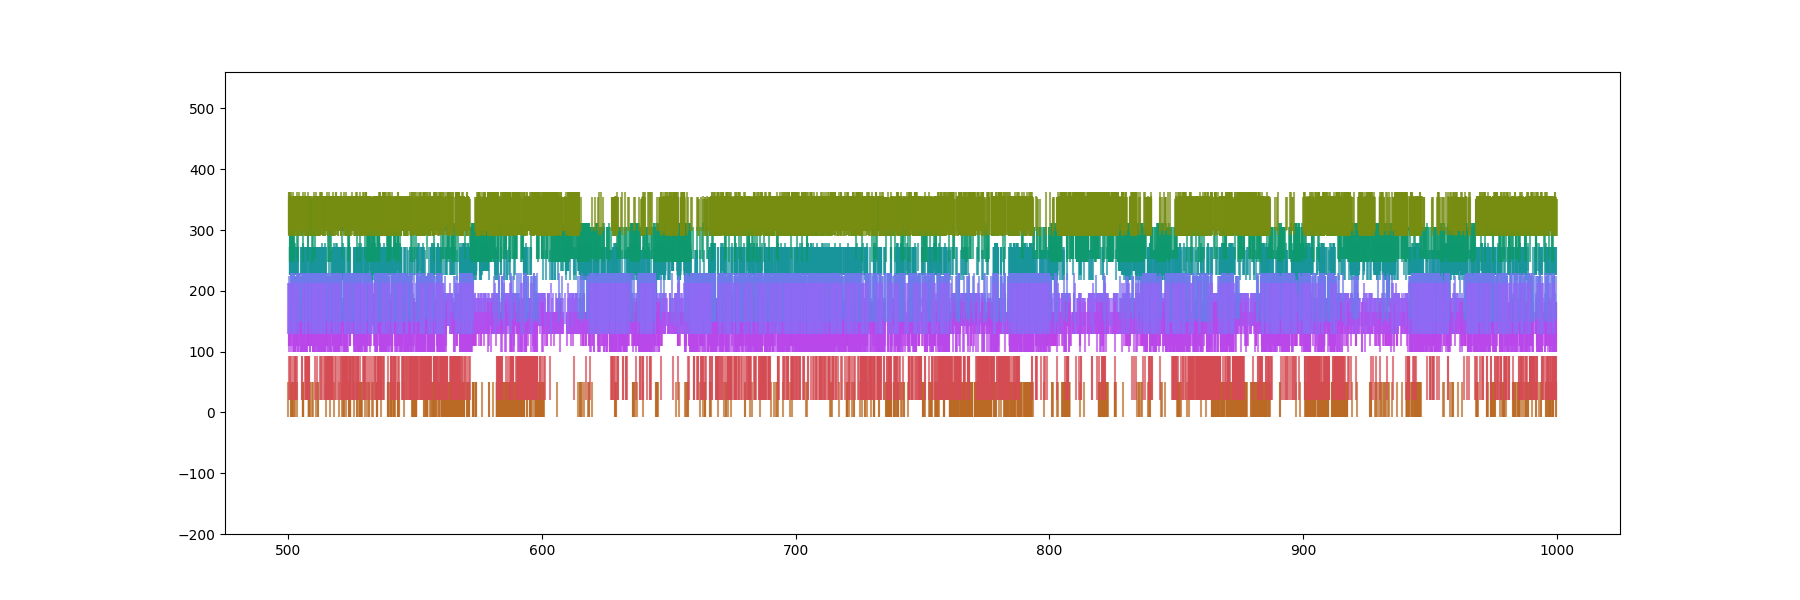

In [268]:
%matplotlib ipympl
window = nap.IntervalSet(start=500, end=1000)
plt.figure(figsize=(18, 6))
for unit_idx in hd_spikes:
    plt.eventplot(spikes[unit_idx].restrict(window).t, color=colors[unit_idx], lineoffsets=np.rad2deg(spikes['pref_ang'][unit_idx]), linelengths=spikes['fwhm'][unit_idx], alpha=0.7)
plt.ylim(-200, 560)

In [261]:
decoded, p_f = nap.decode_bayes(tcs, spikes, epochs=window, bin_size=0.1)

(-200.0, 560.0)

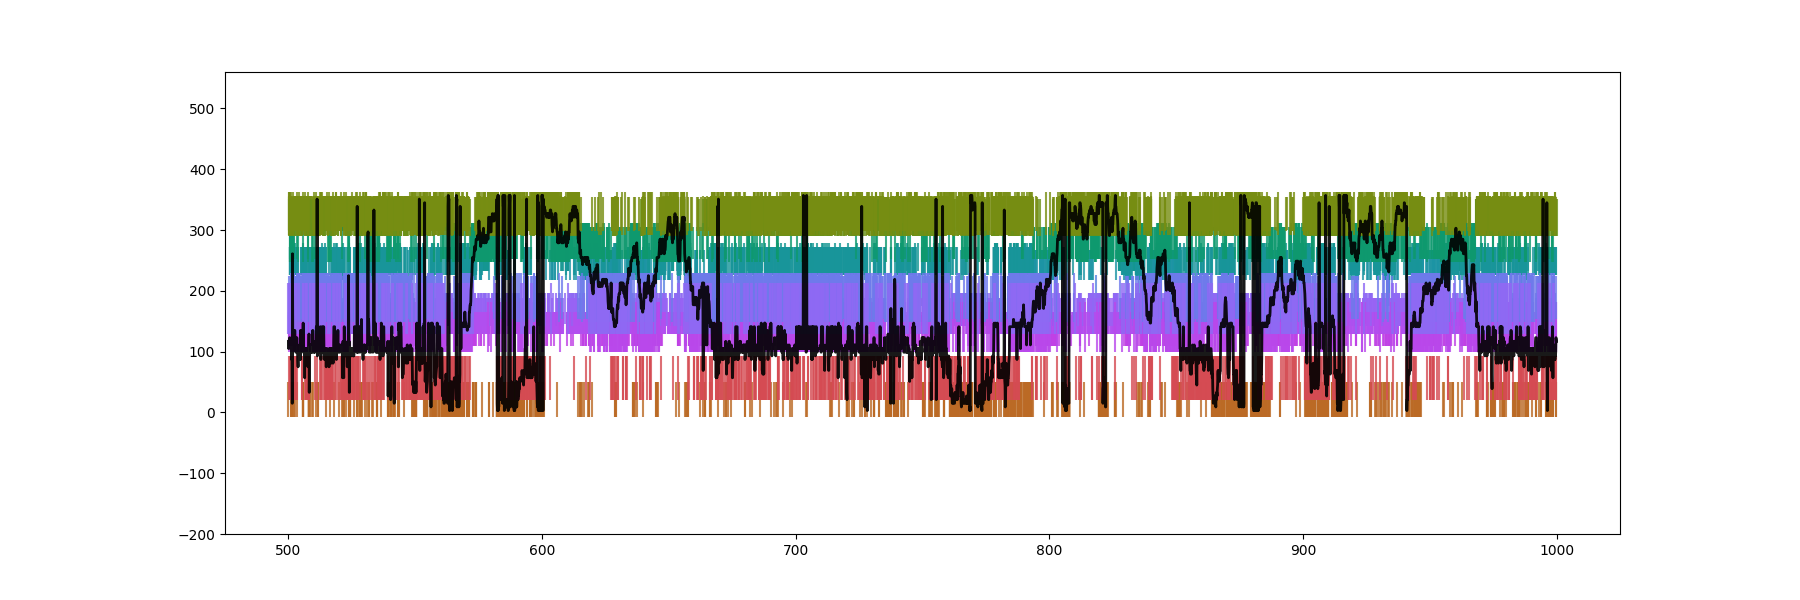

In [269]:
%matplotlib ipympl
window = nap.IntervalSet(start=500, end=1000)
plt.figure(figsize=(18, 6))
for unit_idx in hd_spikes:
    plt.eventplot(spikes[unit_idx].restrict(window).t, color=colors[unit_idx], lineoffsets=np.rad2deg(spikes['pref_ang'][unit_idx]), linelengths=spikes['fwhm'][unit_idx], alpha=0.8)
plt.plot(np.rad2deg(decoded), color='k', linewidth=2, alpha=0.9, zorder=3)
plt.ylim(-200, 560)

In [28]:
hd_spikes.save(PROCESSED_DATA_PATH / unit_id / "hd_spikes")